# Soybean Rust (SBR) Early Warning — Notebook 1 (v3): Improving the model

Notebook v2 showed a real, biologically sensible weather signal, but weak prediction of the following year.
v3 tests the next steps agreed in the walkthrough document, one at a time, with the same time-based validation:

| Step | What changes | Section |
|---|---|---|
| Complete CHIRPS rainfall | Read directly from the producer's (CHC) daily files instead of the gappy NOAA copy | 6 |
| Zero scores | Compare keeping all trials vs excluding trials that were probably not assessed | 7 |
| Target | Trial **mean** severity vs **p90** (severity on the most susceptible genotypes) | 7 |
| Genotype-level model | Predict every genotype × trial record, adding each genotype's susceptibility | 7 |
| Outbreak classification | Predict "will this trial have an outbreak (score ≥ 3)?" with class weighting | 8 |

Weather source: **ECMWF IFS 9 km** (the best source in v2) plus **CHIRPS 5 km** rainfall. Study area: **Malawi and Zambia**.

**How to run:** `Runtime → Run all`, upload `Soybean_Rust_PAT_database_MT2.csv` when asked. The first run downloads weather (about 10–15 minutes); re-runs in the same session use the cache.

## 0. Setup and settings

In [1]:
import os, io, time, json, warnings, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60); pd.set_option('display.width', 200)
plt.rcParams['figure.dpi'] = 110

try:
    import rasterio                                   # reads CHIRPS files over the internet
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'rasterio'], check=True)
    import rasterio

# ---------------- SETTINGS ----------------
CSV_PATH      = 'Soybean_Rust_PAT_database_MT2.csv'
COUNTRIES     = ['Malawi', 'Zambia']   # study area (Tanzania's 2 irrigated trials had no rust)
ANCHOR_STAGE  = 'R4'                   # symptom date for the 14-day window: 'R4' or 'R6'
WINDOW_DAYS   = 14
OM_MODEL      = 'ecmwf_ifs'            # Open-Meteo model: ECMWF IFS 9 km
CACHE_DIR     = 'weather_cache'
OUTBREAK_SCORE = 3                     # outbreak = at least one genotype scored >= 3 (Favoretto et al. 2025 site criterion)

T_LOW, T_HIGH  = 17, 29                # favourable temperature (Favoretto et al. 2025)
RH_WET         = 90                    # wet hour = RH >= 90% (leaf-wetness proxy)
MIN_WET_HOURS  = 6                     # wet hours needed for infection (Melching et al. 1989)
os.makedirs(CACHE_DIR, exist_ok=True)

In [2]:
if not os.path.exists(CSV_PATH):
    try:
        from google.colab import files
        print('Please upload', CSV_PATH)
        up = files.upload(); CSV_PATH = list(up.keys())[0]
    except ImportError:
        raise FileNotFoundError(f'{CSV_PATH} not found. Put it next to this notebook.')
print('Using', CSV_PATH)

Please upload Soybean_Rust_PAT_database_MT2.csv


Saving Soybean_Rust_PAT_database_MT2.csv to Soybean_Rust_PAT_database_MT2.csv
Using Soybean_Rust_PAT_database_MT2.csv


## 1. Load and clean

Same as v2, with one fix: the date reader now also copes with other date layouts, because harvest dates came out empty in the v2 Colab run.

In [3]:
raw = pd.read_csv(CSV_PATH)

def parse_dates(s):
    '''Read day/month/year dates; if most fail, try other layouts (day first).'''
    s = s.astype(str).str.strip()
    d = pd.to_datetime(s, format='%d/%m/%Y', errors='coerce')
    if d.isna().mean() > 0.5:
        d = pd.to_datetime(s, dayfirst=True, errors='coerce', format='mixed')
    return d

df = raw.copy()
df['SOWING'], df['HARVEST'] = parse_dates(df['SOWING']), parse_dates(df['HARVEST'])
print('Unreadable dates -> sowing:', df.SOWING.isna().sum(), '| harvest:', df.HARVEST.isna().sum())
if df.HARVEST.isna().all():
    print('Harvest still unreadable; first raw values:', raw['HARVEST'].head(3).tolist())

bad = df['HARVEST'] < df['SOWING']
print('Harvest before sowing (fixed by +1 year):', bad.sum(), list(df.loc[bad, 'env'].unique()))
df.loc[bad, 'HARVEST'] += pd.DateOffset(years=1)

for c in ['FLW_DAYS', 'NDM', 'W100G', 'PH_R8']:
    df[c] = df[c].replace(0, np.nan)
df = df.rename(columns={'R6_RUST_Se': 'rust'})

df = df[df['COUNTRY'].isin(COUNTRIES)].copy()
print(df.shape, '| trials:', df.env.nunique(), '| countries:', df.COUNTRY.value_counts().to_dict())

Unreadable dates -> sowing: 0 | harvest: 0
Harvest before sowing (fixed by +1 year): 256 ['E017', 'E075', 'E0169', 'E0199', 'E0241', 'E0242', 'E0248', 'E0266', 'E0275', 'E0289', 'E0290']
(3573, 41) | trials: 99 | countries: {'Malawi': 2363, 'Zambia': 1210}


## 2. Zero scores: flag trials that were probably not assessed

A trial is flagged **likely not assessed** when every genotype scored 0 for rust **and** no other disease was recorded in it either.
Zeros are then recoded as 1 (no rust) as before; the flag lets Section 7 compare results with and without those trials.

In [4]:
other = [c for c in df.columns if c.startswith('R6_') and c != 'R6_RUST_RR']
trial_zero = df.groupby('env').agg(rust_max=('rust', 'max'))
trial_zero['other_disease_scored'] = df.groupby('env')[other].max().gt(0).any(axis=1)
trial_zero['likely_unassessed'] = (trial_zero.rust_max == 0) & (~trial_zero.other_disease_scored)
print('Trials flagged likely not assessed:', trial_zero.likely_unassessed.sum())
print(sorted(trial_zero.index[trial_zero.likely_unassessed]))

df['rust'] = df['rust'].replace(0, 1)

Trials flagged likely not assessed: 21
['E0104', 'E0157', 'E0160', 'E0169', 'E0170', 'E0171', 'E0172', 'E0173', 'E0174', 'E0175', 'E0176', 'E019', 'E020', 'E0215', 'E0225', 'E0241', 'E0242', 'E0254', 'E0280', 'E0284', 'E034']


## 3. Trial table and genotype table

In [5]:
def p90(s): return s.quantile(0.9)
env = (df.groupby('env')
         .agg(country=('COUNTRY','first'), loc=('loc','first'), year=('YEAR','first'), season=('SEASON','first'),
              water=('RAINFED','first'), lat=('LAT','first'), lon=('LON','first'), sowing=('SOWING','min'),
              flw_days=('FLW_DAYS','median'), ndm=('NDM','median'), n_gen=('gen','nunique'),
              sev_mean=('rust','mean'), sev_p90=('rust', p90), sev_max=('rust','max'))
         .reset_index())
env = env.merge(trial_zero[['likely_unassessed']], left_on='env', right_index=True)
env['outbreak'] = (env['sev_max'] >= OUTBREAK_SCORE).astype(int)

geno = df[['env', 'gen', 'rust']].copy()          # one row per genotype x trial (replicates already averaged)
print('Trials:', len(env), '| records:', len(geno), '| outbreak trials:', env.outbreak.sum(),
      '| likely not assessed:', env.likely_unassessed.sum())
env[['sev_mean', 'sev_p90', 'sev_max']].describe().round(2)

Trials: 99 | records: 3573 | outbreak trials: 34 | likely not assessed: 21


,sev_mean,sev_p90,sev_max
count,99.00,99.00,99.00
mean,1.37,1.70,2.06
std,0.68,1.14,1.39
min,1.00,1.00,1.00
25%,1.00,1.00,1.00
50%,1.00,1.00,1.00
75%,1.42,2.10,3.00
max,3.90,5.00,5.00


## 4. Growth stages (same as v2)

R4 = R1 + 0.33 × (R8 − R1) and R6 = R1 + 0.60 × (R8 − R1), from the Manitoba Soybean Plant Development Guide proportions.

In [6]:
MED_R1, MED_R8 = env['flw_days'].median(), env['ndm'].median()
env['R1_days'] = env['flw_days'].fillna(MED_R1)
env['R8_days'] = env['ndm'].fillna(MED_R8)
env.loc[env['R8_days'] <= env['R1_days'] + 20, 'R8_days'] = env['R1_days'] + (MED_R8 - MED_R1)
env['R4_days'] = env['R1_days'] + 0.33 * (env['R8_days'] - env['R1_days'])
env['R6_days'] = env['R1_days'] + 0.60 * (env['R8_days'] - env['R1_days'])
for s in ['R1', 'R4', 'R6', 'R8']:
    env[f'{s}_date'] = env['sowing'] + pd.to_timedelta(env[f'{s}_days'].round(), unit='D')
env['dl_start'] = env['R4_date'] - pd.Timedelta(days=WINDOW_DAYS + 1)
env['dl_end']   = env['R6_date'] + pd.Timedelta(days=1)
print(f'Median days after sowing: R1={env.R1_days.median():.0f} R4={env.R4_days.median():.0f} '
      f'R6={env.R6_days.median():.0f} R8={env.R8_days.median():.0f}')

Median days after sowing: R1=49 R4=69 R6=86 R8=110


## 5. Hourly weather: ECMWF IFS 9 km

Same download as v2, for IFS only (the best source in the v2 comparison).

In [7]:
OM_URL = 'https://archive-api.open-meteo.com/v1/archive'
HOURLY = ['temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'precipitation', 'shortwave_radiation',
          'wind_speed_10m', 'wind_direction_10m', 'vapour_pressure_deficit', 'soil_moisture_0_to_7cm']

def get_openmeteo(model, env_id, lat, lon, start, end):
    folder = os.path.join(CACHE_DIR, model); os.makedirs(folder, exist_ok=True)
    path = f'{folder}/{env_id}.csv'
    if os.path.exists(path):
        return pd.read_csv(path, parse_dates=['time'])
    params = dict(latitude=round(lat, 5), longitude=round(lon, 5), models=model,
                  start_date=start.strftime('%Y-%m-%d'), end_date=end.strftime('%Y-%m-%d'),
                  hourly=','.join(HOURLY), timezone='auto', wind_speed_unit='ms', cell_selection='land')
    for attempt in range(5):
        try:
            r = requests.get(OM_URL, params=params, timeout=120)
            if r.status_code == 429: time.sleep(30 * (attempt + 1)); continue
            if r.status_code == 400: print(f'  {env_id}: rejected -> {r.json().get("reason")}'); return None
            r.raise_for_status()
            h = pd.DataFrame(r.json()['hourly']); h['time'] = pd.to_datetime(h['time'])
            h.to_csv(path, index=False); time.sleep(0.3)
            return h
        except Exception as ex:
            print(f'  {env_id}: attempt {attempt+1} failed: {ex}'); time.sleep(5 * (attempt + 1))
    return None

hourly = {}
for i, r in env.iterrows():
    hourly[r['env']] = get_openmeteo(OM_MODEL, r['env'], r['lat'], r['lon'], r['dl_start'], r['dl_end'])
print('IFS weather for', sum(v is not None for v in hourly.values()), 'of', len(env), 'trials')

IFS weather for 99 of 99 trials


## 6. Complete CHIRPS rainfall from the producer (CHC)

In v2 the NOAA copy of CHIRPS had gaps, so only 36 trials got CHIRPS rain. Here each day's CHIRPS file
(0.05°, ~5.5 km) is read **directly from the Climate Hazards Center**, taking only the pixels at the trial sites
(the files are "cloud-optimised", so the whole map is not downloaded). About 1,000 days are needed; they are read in parallel and cached.

In [8]:
from concurrent.futures import ThreadPoolExecutor
CHC_URL = 'https://data.chc.ucsb.edu/products/CHIRPS-2.0/global_daily/cogs/p05/{d:%Y}/chirps-v2.0.{d:%Y.%m.%d}.cog'
chirps_dir = os.path.join(CACHE_DIR, 'chirps_chc'); os.makedirs(chirps_dir, exist_ok=True)

sites = env[['lat', 'lon']].drop_duplicates().reset_index(drop=True)
sites['site'] = [f's{i}' for i in range(len(sites))]
env = env.merge(sites, on=['lat', 'lon'], how='left')
points = list(zip(sites.lon, sites.lat))                       # rasterio wants (x=lon, y=lat)

days = sorted({d for _, r in env.iterrows() for d in pd.date_range(r['dl_start'], r['dl_end'], freq='D')})
print(f'{len(sites)} unique sites, {len(days)} days to read')

GDAL_ENV = dict(GDAL_DISABLE_READDIR_ON_OPEN='EMPTY_DIR', CPL_VSIL_CURL_ALLOWED_EXTENSIONS='.cog,.tif',
                GDAL_HTTP_MAX_RETRY='4', GDAL_HTTP_RETRY_DELAY='3')

def chirps_day(day):
    path = os.path.join(chirps_dir, f'{day:%Y%m%d}.csv')
    if os.path.exists(path):
        return pd.read_csv(path)
    try:
        with rasterio.Env(**GDAL_ENV):
            with rasterio.open(CHC_URL.format(d=day)) as src:
                vals = [float(v[0]) for v in src.sample(points)]
                nod = src.nodata
        vals = [np.nan if (nod is not None and v == nod) or v < 0 else v for v in vals]
        out = pd.DataFrame({'site': sites.site, 'precip': vals})
        out.to_csv(path, index=False)
        return out
    except Exception as ex:
        return pd.DataFrame({'site': sites.site, 'precip': np.nan, 'error': str(ex)[:80]})

t0 = time.time()
with ThreadPoolExecutor(max_workers=8) as pool:
    results = list(pool.map(chirps_day, days))
chirps_long = pd.concat([r.assign(date=d) for r, d in zip(results, days)], ignore_index=True)
missing_days = chirps_long.groupby('date')['precip'].apply(lambda s: s.isna().all())
print(f'Read in {time.time()-t0:.0f} s | days with no data: {missing_days.sum()} of {len(days)}')
if missing_days.any():
    print('Examples of missing days:', [d.strftime('%Y-%m-%d') for d in missing_days.index[missing_days]][:10])
chirps_wide = chirps_long.pivot(index='date', columns='site', values='precip')

88 unique sites, 949 days to read
Read in 63 s | days with no data: 0 of 949


## 7a. Weather features (IFS, and IFS with CHIRPS rain)

Same 16 epidemiological features as v2 for the 14 days before R4 and before R6. CHIRPS replaces IFS rain wherever it covers at least 90% of the window's days.

CHIRPS rain used for 99 of 99 trials (R4 window)


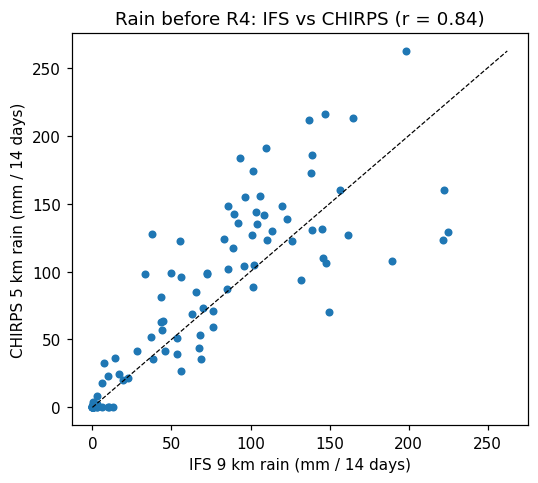

In [9]:
def window_features(h, rain_daily=None):
    if h is None or h.empty:
        return {}
    h = h.copy()
    h['date'] = h['time'].dt.normalize()
    h['wet'] = (h['relative_humidity_2m'] >= RH_WET).where(h['relative_humidity_2m'].notna())
    d = h.groupby('date').agg(tmin=('temperature_2m', 'min'), tmax=('temperature_2m', 'max'),
                              rain=('precipitation', lambda s: s.sum(min_count=1)),
                              wet_h=('wet', lambda s: s.sum(min_count=1)))
    d['wet_T'] = h[h['wet'] == True].groupby('date')['temperature_2m'].mean().reindex(d.index)
    used_chirps = False
    if rain_daily is not None:
        rd = rain_daily.reindex(d.index)
        if rd.notna().mean() >= 0.9:
            d['rain'] = rd; used_chirps = True
    infect = (d['wet_h'] >= MIN_WET_HOURS) & d['wet_T'].between(T_LOW, T_HIGH)
    nan_if_empty = lambda s, v: v if s.notna().any() else np.nan
    wd = np.deg2rad(h['wind_direction_10m'])
    return {'wet_hours': nan_if_empty(h['wet'], h['wet'].sum()),
            'wet_days6': nan_if_empty(d['wet_h'], (d['wet_h'] >= MIN_WET_HOURS).sum()),
            'infect_days': nan_if_empty(d['wet_h'], infect.sum()),
            'tmin': d['tmin'].mean(), 'tmax': d['tmax'].mean(),
            'hot_days': nan_if_empty(d['tmax'], (d['tmax'] > 30).sum()),
            'hours_T17_29': nan_if_empty(h['temperature_2m'], h['temperature_2m'].between(T_LOW, T_HIGH).sum()),
            'rain_total': d['rain'].sum(min_count=1), 'rain_days': nan_if_empty(d['rain'], (d['rain'] >= 1).sum()),
            'rh_mean': h['relative_humidity_2m'].mean(), 'vpd_mean': h['vapour_pressure_deficit'].mean(),
            'srad': h['shortwave_radiation'].mean(), 'wind': h['wind_speed_10m'].mean(),
            'wind_sin': np.sin(wd).mean(), 'wind_cos': np.cos(wd).mean(),
            'soilm': h['soil_moisture_0_to_7cm'].mean(), 'rain_from_chirps': int(used_chirps)}

tables = {}
for label, use_chirps in [('IFS', False), ('IFS+CHIRPS', True)]:
    rows = []
    for _, r in env.iterrows():
        h = hourly.get(r['env']); feats = {'env': r['env']}
        rain = chirps_wide[r['site']] if (use_chirps and r['site'] in chirps_wide) else None
        for stage in ['R4', 'R6']:
            end = r[f'{stage}_date']; start = end - pd.Timedelta(days=WINDOW_DAYS)
            w = None if h is None else h[(h['time'] >= start) & (h['time'] < end)]
            feats.update({f'{stage}_{k}': v for k, v in window_features(w, rain).items()})
        rows.append(feats)
    tables[label] = pd.DataFrame(rows)

FEATURES = [f'{ANCHOR_STAGE}_{f}' for f in ['wet_hours', 'wet_days6', 'infect_days', 'tmin', 'tmax', 'hot_days',
            'hours_T17_29', 'rain_total', 'rain_days', 'rh_mean', 'vpd_mean', 'srad', 'wind', 'wind_sin', 'wind_cos', 'soilm']]
ch = tables['IFS+CHIRPS']
print(f'CHIRPS rain used for {ch[f"{ANCHOR_STAGE}_rain_from_chirps"].sum()} of {len(ch)} trials ({ANCHOR_STAGE} window)')

a = tables['IFS'].set_index('env')[f'{ANCHOR_STAGE}_rain_total']; b = ch.set_index('env')[f'{ANCHOR_STAGE}_rain_total']
fig, ax = plt.subplots(figsize=(5, 4.5))
ax.scatter(a, b.reindex(a.index), s=18); lim = [0, np.nanmax([a.max(), b.max()])]; ax.plot(lim, lim, 'k--', lw=0.8)
ax.set_xlabel('IFS 9 km rain (mm / 14 days)'); ax.set_ylabel('CHIRPS 5 km rain (mm / 14 days)')
ax.set_title(f'Rain before {ANCHOR_STAGE}: IFS vs CHIRPS (r = {a.corr(b.reindex(a.index)):.2f})'); plt.tight_layout(); plt.show()

## 7b. Regression experiments (predict the 1–5 severity)

Every experiment uses the same forward chaining (train on earlier years, predict the next year) and the same three models
(baseline, Ridge, random forest). Because excluding trials changes the test set, each experiment is judged mainly by
**how much it beats its own baseline** on trials that had rust (`gain_vs_baseline`, in %), and by `spearman`.

| Experiment | Features | Target | Trials |
|---|---|---|---|
| E1 | IFS | mean | all (v2 set-up, for reference) |
| E2 | IFS + CHIRPS | mean | all |
| E3 | IFS + CHIRPS | mean | excluding likely not assessed |
| E4 | IFS + CHIRPS | p90 | all |
| E5 | IFS + CHIRPS | p90 | excluding likely not assessed |
| E6 | IFS + CHIRPS + genotype susceptibility | each genotype's score | excluding likely not assessed |

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr

REG_MODELS = {
    'Baseline': lambda: DummyRegressor(strategy='mean'),
    'Ridge': lambda: make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 30))),
    'Random forest': lambda: make_pipeline(SimpleImputer(strategy='median'),
                        RandomForestRegressor(n_estimators=500, min_samples_leaf=4, max_features=0.5, random_state=42, n_jobs=-1)),
}

def forward_chain(data, X_cols, y_col, models, prepare=None):
    '''Train on years before each test year, predict that year. prepare(train, test) may add training-only columns.'''
    out = []
    for ty in sorted(data['year'].unique())[2:]:
        tr, te = data[data.year < ty].copy(), data[data.year == ty].copy()
        if prepare is not None:
            tr, te = prepare(tr, te)
        for name, make in models.items():
            m = make().fit(tr[X_cols], tr[y_col])
            p = m.predict_proba(te[X_cols])[:, 1] if hasattr(m, 'predict_proba') else np.clip(m.predict(te[X_cols]), 1, 5)
            out.append(te[['env', 'year']].assign(model=name, obs=te[y_col].values, pred=p,
                                                   **({'gen': te['gen'].values} if 'gen' in te else {})))
    return pd.concat(out, ignore_index=True)

def reg_scores(g):
    rust = g.obs >= 1.5
    return pd.Series({'n': len(g), 'MAE': np.abs(g.obs - g.pred).mean(),
                      'MAE_rust': np.abs(g.obs - g.pred)[rust].mean(), 'spearman': spearmanr(g.obs, g.pred)[0]})

def summarise(preds, exp):
    s = preds.groupby('model').apply(reg_scores)
    base = s.loc['Baseline', 'MAE_rust']
    s['gain_vs_baseline_%'] = (base - s['MAE_rust']) / base * 100
    return s.assign(experiment=exp).reset_index()

def trial_data(features, exclude):
    d = env.merge(tables[features], on='env')
    return d[~d.likely_unassessed] if exclude else d

EXPERIMENTS = {'E1 IFS, mean, all': ('IFS', 'sev_mean', False),
               'E2 IFS+CHIRPS, mean, all': ('IFS+CHIRPS', 'sev_mean', False),
               'E3 IFS+CHIRPS, mean, assessed only': ('IFS+CHIRPS', 'sev_mean', True),
               'E4 IFS+CHIRPS, p90, all': ('IFS+CHIRPS', 'sev_p90', False),
               'E5 IFS+CHIRPS, p90, assessed only': ('IFS+CHIRPS', 'sev_p90', True)}
all_preds, results = {}, []
for exp, (feat, target, excl) in EXPERIMENTS.items():
    d = trial_data(feat, excl)
    all_preds[exp] = forward_chain(d, FEATURES, target, REG_MODELS)
    results.append(summarise(all_preds[exp], exp))
    print(f'{exp}: {len(d)} trials')

E1 IFS, mean, all: 99 trials
E2 IFS+CHIRPS, mean, all: 99 trials
E3 IFS+CHIRPS, mean, assessed only: 78 trials
E4 IFS+CHIRPS, p90, all: 99 trials
E5 IFS+CHIRPS, p90, assessed only: 78 trials


### E6 — genotype-level model

Each row is one genotype in one trial (about 3,000 records instead of about 90 trials). Besides the trial's weather, the model gets
`gen_suscept`: the genotype's average rust score **in the training years only** (pulled towards the overall average when a genotype
has few records; genotypes never seen before get the overall average). Computing it from training years only prevents the model
from peeking at the answer. Predictions are then averaged per trial so they can be compared with E3.

In [11]:
SHRINK = 5   # a genotype with 5 training records is weighted half its own mean, half the overall mean

def add_suscept(tr, te):
    overall = tr['rust'].mean()
    g = tr.groupby('gen')['rust'].agg(['sum', 'count'])
    score = (g['sum'] + SHRINK * overall) / (g['count'] + SHRINK)
    tr['gen_suscept'] = tr['gen'].map(score)
    te['gen_suscept'] = te['gen'].map(score).fillna(overall)
    return tr, te

gd = geno.merge(trial_data('IFS+CHIRPS', True)[['env', 'year'] + FEATURES], on='env')
G_FEATURES = FEATURES + ['gen_suscept']
p6 = forward_chain(gd, G_FEATURES, 'rust', REG_MODELS, prepare=add_suscept)
all_preds['E6 genotype level (records)'] = p6
results.append(summarise(p6, 'E6 genotype level (records)'))

p6_trial = p6.groupby(['model', 'env', 'year'], as_index=False)[['obs', 'pred']].mean()   # back to trial means
all_preds['E6 genotype level -> trial mean'] = p6_trial
results.append(summarise(p6_trial, 'E6 genotype level -> trial mean'))
print(f'E6: {len(gd)} records in {gd.env.nunique()} trials')

res = pd.concat(results)[['experiment', 'model', 'n', 'MAE', 'MAE_rust', 'gain_vs_baseline_%', 'spearman']].round(3)
display(res)

E6: 2803 records in 78 trials


,experiment,model,n,MAE,MAE_rust,gain_vs_baseline_%,spearman
0,"E1 IFS, mean, all",Baseline,81.0,0.543,1.242,0.000,-0.109
1,"E1 IFS, mean, all",Random forest,81.0,0.457,1.164,6.279,0.233
2,"E1 IFS, mean, all",Ridge,81.0,0.497,1.227,1.181,0.221
0,"E2 IFS+CHIRPS, mean, all",Baseline,81.0,0.543,1.242,0.000,-0.109
1,"E2 IFS+CHIRPS, mean, all",Random forest,81.0,0.457,1.164,6.296,0.236
2,"E2 IFS+CHIRPS, mean, all",Ridge,81.0,0.496,1.226,1.280,0.221
0,"E3 IFS+CHIRPS, mean, assessed only",Baseline,63.0,0.635,1.160,0.000,-0.111
1,"E3 IFS+CHIRPS, mean, assessed only",Random forest,63.0,0.467,1.057,8.909,0.470
2,"E3 IFS+CHIRPS, mean, assessed only",Ridge,63.0,0.549,1.129,2.726,0.367
0,"E4 IFS+CHIRPS, p90, all",Baseline,81.0,1.000,1.596,0.000,-0.025


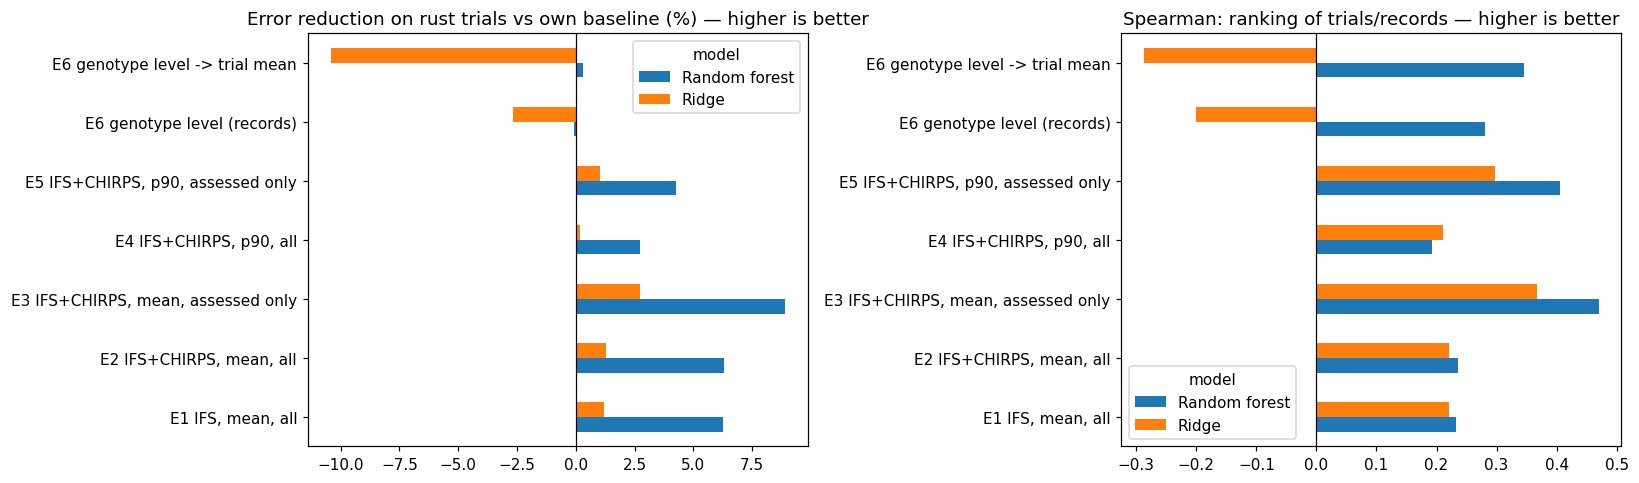

In [12]:
piv = res[res.model != 'Baseline'].pivot(index='experiment', columns='model', values=['gain_vs_baseline_%', 'spearman'])
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
piv['gain_vs_baseline_%'].plot.barh(ax=ax[0]); ax[0].axvline(0, color='k', lw=0.8)
ax[0].set_title('Error reduction on rust trials vs own baseline (%) — higher is better'); ax[0].set_ylabel('')
piv['spearman'].plot.barh(ax=ax[1]); ax[1].axvline(0, color='k', lw=0.8)
ax[1].set_title('Spearman: ranking of trials/records — higher is better'); ax[1].set_ylabel('')
plt.tight_layout(); plt.show()

## 8. Outbreak classification: "will this trial have an outbreak?"

Instead of predicting the exact score, the model predicts the probability that at least one genotype reaches score ≥ 3.
`class_weight='balanced'` makes the rare outbreak trials count as much as the many no-rust trials, so the model is pushed to find them.

Metrics: **recall** (share of real outbreaks that were flagged — the most important for early warning), **precision**
(share of alarms that were real), and **AUC** (0.5 = no better than chance, 1 = perfect separation).

In [13]:
CLF_MODELS = {
    'Baseline': lambda: DummyClassifier(strategy='prior'),
    'Logistic': lambda: make_pipeline(SimpleImputer(strategy='median'), StandardScaler(),
                                      LogisticRegression(C=0.3, class_weight='balanced', max_iter=2000)),
    'Random forest': lambda: make_pipeline(SimpleImputer(strategy='median'),
                        RandomForestClassifier(n_estimators=500, min_samples_leaf=3, max_features=0.5,
                                               class_weight='balanced', random_state=42, n_jobs=-1)),
}

def clf_scores(g, thr=0.5):
    flag = g.pred >= thr
    tp = int((flag & (g.obs == 1)).sum()); fp = int((flag & (g.obs == 0)).sum()); fn = int((~flag & (g.obs == 1)).sum())
    return pd.Series({'trials': len(g), 'outbreaks': int(g.obs.sum()), 'flagged': int(flag.sum()),
                      'detected': tp, 'recall': tp / max(tp + fn, 1), 'precision': tp / max(tp + fp, 1),
                      'AUC': roc_auc_score(g.obs, g.pred) if g.obs.nunique() == 2 else np.nan})

clf_results, clf_preds = [], {}
for label, excl in [('all trials', False), ('assessed only', True)]:
    d = trial_data('IFS+CHIRPS', excl)
    p = forward_chain(d, FEATURES, 'outbreak', CLF_MODELS)
    clf_preds[label] = p
    clf_results.append(p.groupby('model').apply(clf_scores).assign(trials_used=label).reset_index())
clf_res = pd.concat(clf_results)[['trials_used', 'model', 'trials', 'outbreaks', 'flagged', 'detected', 'recall', 'precision', 'AUC']].round(3)
display(clf_res)

,trials_used,model,trials,outbreaks,flagged,detected,recall,precision,AUC
0,all trials,Baseline,81.0,26.0,0.0,0.0,0.000,0.000,0.522
1,all trials,Logistic,81.0,26.0,26.0,8.0,0.308,0.308,0.548
2,all trials,Random forest,81.0,26.0,19.0,8.0,0.308,0.421,0.543
0,assessed only,Baseline,63.0,26.0,29.0,10.0,0.385,0.345,0.389
1,assessed only,Logistic,63.0,26.0,25.0,14.0,0.538,0.560,0.650
2,assessed only,Random forest,63.0,26.0,20.0,12.0,0.462,0.600,0.619


In [14]:
best_clf = clf_res[clf_res.model != 'Baseline'].sort_values(['AUC', 'recall'], ascending=False).iloc[0]
p = clf_preds[best_clf.trials_used]; p = p[p.model == best_clf.model].merge(env[['env', 'country', 'loc', 'sev_max', 'sev_mean']], on='env')
print(f'Best: {best_clf.model}, {best_clf.trials_used}  (AUC {best_clf.AUC:.2f}, recall {best_clf.recall:.2f})\n')
print('Outbreak trials and the probability the model gave them (>= 0.5 = flagged):')
display(p[p.obs == 1].sort_values('pred', ascending=False)[['env', 'year', 'country', 'loc', 'sev_max', 'sev_mean', 'pred']].round(2))
print('False alarms (no outbreak, probability >= 0.5):')
display(p[(p.obs == 0) & (p.pred >= 0.5)][['env', 'year', 'country', 'loc', 'sev_max', 'pred']].round(2))

Best: Logistic, assessed only  (AUC 0.65, recall 0.54)

Outbreak trials and the probability the model gave them (>= 0.5 = flagged):


,env,year,country,loc,sev_max,sev_mean,pred
42,E0251,2022,Malawi,L0105,5,2.52,0.70
43,E0252,2022,Zambia,L098,3,1.56,0.67
24,E0156,2020,Malawi,L011,5,3.90,0.60
14,E096,2019,Malawi,L017,3,1.10,0.60
22,E0154,2020,Malawi,L094,3,2.35,0.59
13,E095,2019,Malawi,L024,4,1.90,0.59
41,E0249,2022,Malawi,L0125,5,1.32,0.56
11,E093,2019,Malawi,L011,5,3.40,0.55
59,E0285,2023,Zambia,L0136,3,1.24,0.54
15,E097,2019,Malawi,L072,4,2.47,0.54


False alarms (no outbreak, probability >= 0.5):


,env,year,country,loc,sev_max,pred
0,E0103,2019,Zambia,L073,1,0.57
1,E0105,2019,Zambia,L075,1,0.56
2,E0106,2019,Zambia,L076,1,0.60
3,E0107,2019,Zambia,L077,2,0.51
12,E094,2019,Malawi,L010,1,0.63
17,E099,2019,Malawi,L015,2,0.52
37,E0228,2021,Zambia,L0118,1,0.50
40,E0248,2022,Malawi,L0124,2,0.57
44,E0253,2022,Zambia,L073,2,0.72
45,E0255,2022,Zambia,L074,1,0.68


### What drives outbreak risk? (random forest, permutation importance on all assessed trials)

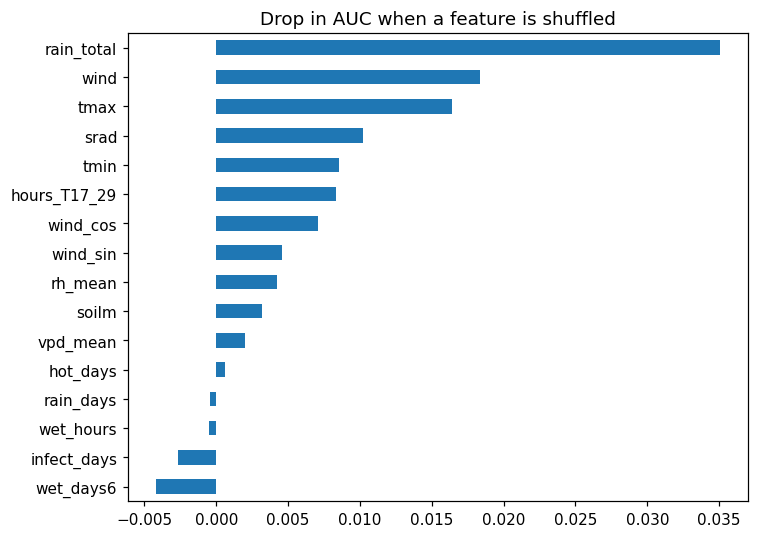

In [15]:
from sklearn.inspection import permutation_importance
d = trial_data('IFS+CHIRPS', True)
rf = CLF_MODELS['Random forest']().fit(d[FEATURES], d['outbreak'])
imp = permutation_importance(rf, d[FEATURES], d['outbreak'], n_repeats=30, random_state=0, scoring='roc_auc')
fig, ax = plt.subplots(figsize=(7, 5))
pd.Series(imp.importances_mean, index=[f.split('_', 1)[1] for f in FEATURES]).sort_values().plot.barh(ax=ax)
ax.set_title('Drop in AUC when a feature is shuffled'); plt.tight_layout(); plt.show()

## 9. Save outputs

In [16]:
res.to_csv('v3_regression_experiments.csv', index=False)
clf_res.to_csv('v3_outbreak_classification.csv', index=False)
env.merge(tables['IFS+CHIRPS'], on='env').to_csv('v3_features_ifs_chirps_complete.csv', index=False)
pd.concat([v.assign(experiment=k) for k, v in all_preds.items()]).to_csv('v3_regression_predictions.csv', index=False)
pd.concat([v.assign(trials_used=k) for k, v in clf_preds.items()]).to_csv('v3_outbreak_predictions.csv', index=False)
saved = ['v3_regression_experiments.csv', 'v3_outbreak_classification.csv', 'v3_features_ifs_chirps_complete.csv',
         'v3_regression_predictions.csv', 'v3_outbreak_predictions.csv']
print('Saved:', *saved, sep='\n  ')
try:
    from google.colab import files
    for f in saved: files.download(f)
except ImportError:
    pass

Saved:
  v3_regression_experiments.csv
  v3_outbreak_classification.csv
  v3_features_ifs_chirps_complete.csv
  v3_regression_predictions.csv
  v3_outbreak_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## How to read the results

* **CHIRPS (Section 7a):** check how many trials now use CHIRPS rain (should be close to all) and how well it agrees with IFS rain.
* **E1 vs E2:** does complete CHIRPS rainfall help?
* **E2 vs E3 and E4 vs E5:** does removing the likely-unassessed trials give a clearer signal? (Final decision depends on Dr. Harun.)
* **E2 vs E4:** is p90 (disease pressure) easier to predict than the mean?
* **E6:** does knowing each genotype's susceptibility improve predictions?
* **Section 8:** how many real outbreaks the classifier flags (recall), how many false alarms, and AUC. For an early warning system, recall matters most.

With about 90 trials, differences of a few percent can be chance; look for improvements that are consistent across models.